# Heston Stochastic Volatility Model

## Objectives

This notebook studies the dynamics and economic interpretation of the Heston stochastic-volatility model.

The main objectives are:

1. simulate joint stock-price and variance paths;
2. examine mean reversion in the variance process;
3. validate simulated average variance against the analytical expectation;
4. study the effects of the mean-reversion parameter $\kappa$;
5. study the effects of the volatility-of-variance parameter $\xi$;
6. examine the role of correlation $\rho$ and the leverage effect;
7. compare Heston and constant-volatility GBM return distributions;
8. motivate Heston option pricing and calibration.

In [1]:
import sys
from pathlib import Path

project_root = Path(
    "/Users/amber/derivatives-pricing-calibration"
).resolve()

assert (project_root / "src").exists(), (
    f"Cannot find src folder under {project_root}"
)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

figure_dir = project_root / "figures"
figure_dir.mkdir(exist_ok=True)

print("Project root:", project_root)
print("Python executable:", sys.executable)

Project root: /Users/amber/derivatives-pricing-calibration
Python executable: /Users/amber/derivatives-pricing-calibration/.venv/bin/python


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis

from src.models.heston import (
    expected_variance,
    feller_condition,
    simulate_heston_paths,
)

from src.pricing.monte_carlo import (
    simulate_terminal_prices,
)

## 1. Heston Model Dynamics

The Heston model extends Black-Scholes by replacing constant volatility with a stochastic variance process.

The stock price follows

$$
dS_t
=
rS_t\,dt
+
\sqrt{v_t}S_t\,dW_t^S,
$$

while variance follows

$$
dv_t
=
\kappa(\theta-v_t)\,dt
+
\xi\sqrt{v_t}\,dW_t^v.
$$

The Brownian shocks are correlated according to

$$
dW_t^S dW_t^v
=
\rho\,dt.
$$

The model contains five key variance-related parameters:

- $v_0$: initial variance;
- $\kappa$: variance mean-reversion speed;
- $\theta$: long-run variance;
- $\xi$: volatility of variance, or vol-of-vol;
- $\rho$: correlation between stock-return and variance shocks.

The instantaneous volatility is

$$
\sigma_t=\sqrt{v_t}.
$$

Unlike Black-Scholes, volatility is therefore dynamic and random.

In [3]:
S0 = 100.0
v0 = 0.09

T = 2.0
r = 0.03

kappa = 2.0
theta = 0.04
xi = 0.30
rho = -0.70

n_paths = 5_000
n_steps = 504

print(
    "Initial volatility:",
    np.sqrt(v0),
)

print(
    "Long-run volatility:",
    np.sqrt(theta),
)

print(
    "Feller condition satisfied:",
    feller_condition(
        kappa,
        theta,
        xi,
    ),
)

Initial volatility: 0.3
Long-run volatility: 0.2
Feller condition satisfied: True


## 2. Feller Condition

The Heston variance process is a CIR-type process.

A commonly used sufficient condition for strict positivity of the continuous-time variance process is

$$
2\kappa\theta>\xi^2.
$$

If the condition holds, variance remains strictly positive in the theoretical continuous-time process.

Failure of the Feller condition does not automatically make the Heston model unusable. However, the variance process may approach or reach zero, making numerical implementation more delicate.

The simulation used in this project therefore applies a positivity-truncated Euler approximation.

In [4]:
(
    times,
    stock_paths,
    variance_paths,
) = simulate_heston_paths(
    S0=S0,
    v0=v0,
    T=T,
    r=r,
    kappa=kappa,
    theta=theta,
    xi=xi,
    rho=rho,
    n_paths=n_paths,
    n_steps=n_steps,
    seed=42,
)

print(
    "Stock paths shape:",
    stock_paths.shape,
)

print(
    "Variance paths shape:",
    variance_paths.shape,
)

print(
    "Minimum simulated variance:",
    variance_paths.min(),
)

Stock paths shape: (5000, 505)
Variance paths shape: (5000, 505)
Minimum simulated variance: 0.0


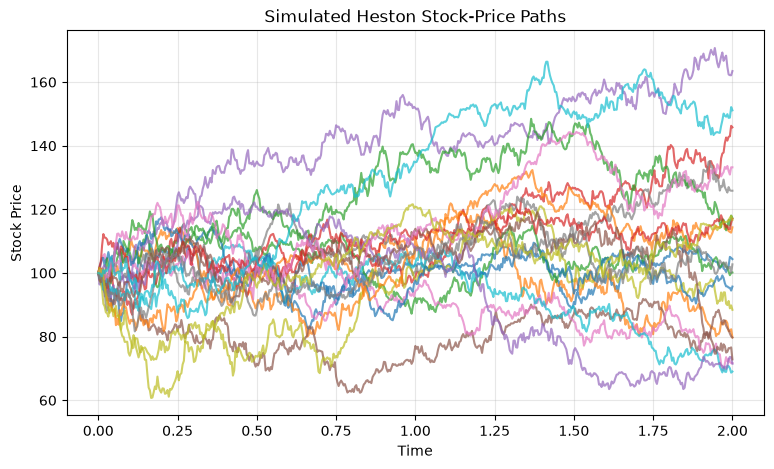

In [5]:
plt.figure(
    figsize=(9, 5),
)

for path in stock_paths[:20]:
    plt.plot(
        times,
        path,
        alpha=0.7,
    )

plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.title("Simulated Heston Stock-Price Paths")
plt.grid(alpha=0.3)

plt.savefig(
    figure_dir / "heston_stock_paths.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

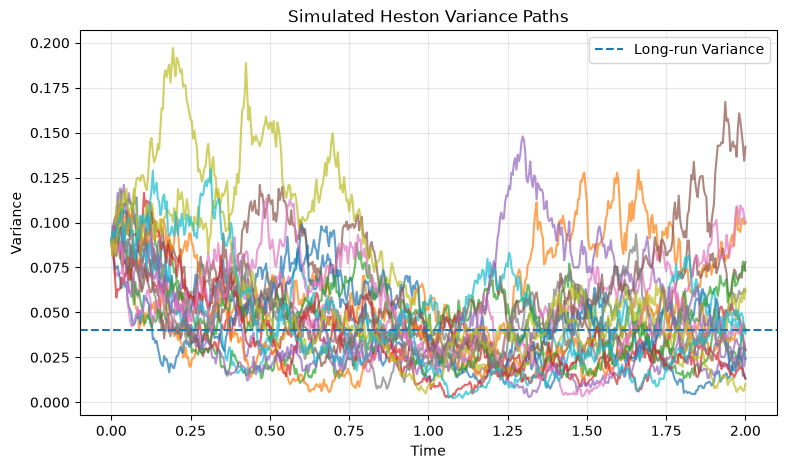

In [6]:
plt.figure(
    figsize=(9, 5),
)

for path in variance_paths[:20]:
    plt.plot(
        times,
        path,
        alpha=0.7,
    )

plt.axhline(
    theta,
    linestyle="--",
    label="Long-run Variance",
)

plt.xlabel("Time")
plt.ylabel("Variance")
plt.title("Simulated Heston Variance Paths")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    figure_dir / "heston_variance_paths.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 3. Mean-Reversion Validation

The drift of the Heston variance process is

$$
\kappa(\theta-v_t).
$$

If

$$
v_t>\theta,
$$

the drift is negative and pushes variance downward.

If

$$
v_t<\theta,
$$

the drift is positive and pushes variance upward.

The theoretical expectation of variance is

$$
\mathbb E[v_t]
=
\theta
+
(v_0-\theta)e^{-\kappa t}.
$$

This provides an analytical benchmark against which the Monte Carlo simulation can be validated.

In [7]:
simulated_mean_variance = np.mean(
    variance_paths,
    axis=0,
)

theoretical_mean_variance = (
    expected_variance(
        times,
        v0=v0,
        kappa=kappa,
        theta=theta,
    )
)

mean_variance_error = np.abs(
    simulated_mean_variance
    - theoretical_mean_variance
)

print(
    "Maximum mean-variance error:",
    mean_variance_error.max(),
)

print(
    "Mean mean-variance error:",
    mean_variance_error.mean(),
)

Maximum mean-variance error: 0.001216681764292106
Mean mean-variance error: 0.0003829791826741566


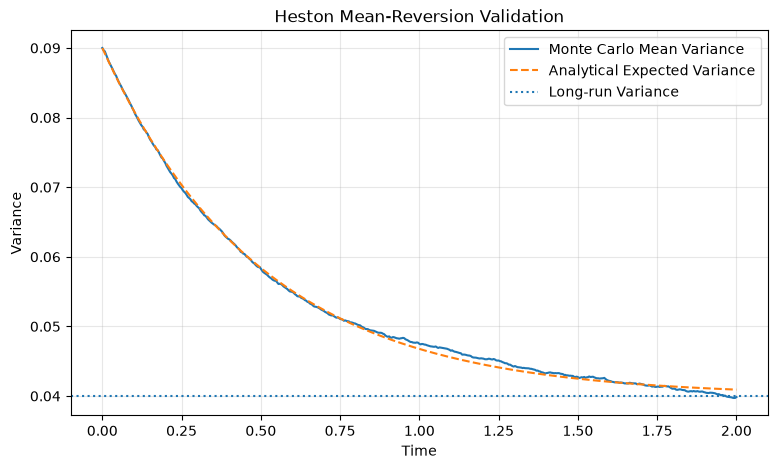

In [8]:
plt.figure(
    figsize=(9, 5),
)

plt.plot(
    times,
    simulated_mean_variance,
    label="Monte Carlo Mean Variance",
)

plt.plot(
    times,
    theoretical_mean_variance,
    linestyle="--",
    label="Analytical Expected Variance",
)

plt.axhline(
    theta,
    linestyle=":",
    label="Long-run Variance",
)

plt.xlabel("Time")
plt.ylabel("Variance")
plt.title(
    "Heston Mean-Reversion Validation"
)

plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    figure_dir / "heston_mean_reversion_validation.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [9]:
validation_times = np.array([
    0.25,
    0.50,
    1.00,
    1.50,
    2.00,
])

validation_rows = []

for t in validation_times:

    index = np.argmin(
        np.abs(times - t)
    )

    analytical_value = (
        theoretical_mean_variance[index]
    )

    simulated_value = (
        simulated_mean_variance[index]
    )

    validation_rows.append({
        "Time": times[index],
        "Analytical E[v_t]": analytical_value,
        "Simulated Mean Variance": simulated_value,
        "Absolute Error": abs(
            simulated_value
            - analytical_value
        ),
    })

mean_reversion_results = pd.DataFrame(
    validation_rows
)

mean_reversion_results

,Time,Analytical E[v_t],Simulated Mean Variance,Absolute Error
0,0.25,0.070327,0.069868,0.000459
1,0.50,0.058394,0.058289,0.000105
2,1.00,0.046767,0.047495,0.000728
3,1.50,0.042489,0.042723,0.000234
4,2.00,0.040916,0.039847,0.001069


## 4. Effect of Mean-Reversion Speed $\kappa$

The parameter $\kappa$ controls how rapidly variance returns toward the long-run level $\theta$.

A larger value of $\kappa$ implies faster mean reversion.

To isolate this effect, all other Heston parameters are held fixed while $\kappa$ is varied.

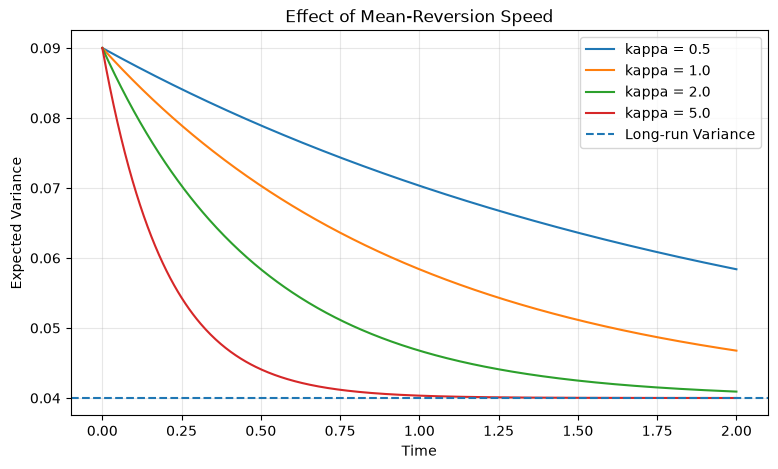

In [10]:
kappa_values = [
    0.5,
    1.0,
    2.0,
    5.0,
]

plt.figure(
    figsize=(9, 5),
)

for kappa_value in kappa_values:

    curve = expected_variance(
        times,
        v0=v0,
        kappa=kappa_value,
        theta=theta,
    )

    plt.plot(
        times,
        curve,
        label=(
            f"kappa = {kappa_value}"
        ),
    )

plt.axhline(
    theta,
    linestyle="--",
    label="Long-run Variance",
)

plt.xlabel("Time")
plt.ylabel("Expected Variance")
plt.title(
    "Effect of Mean-Reversion Speed"
)

plt.legend()
plt.grid(alpha=0.3)

plt.savefig(
    figure_dir / "heston_kappa_effect.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 5. Effect of Volatility of Variance $\xi$

The parameter $\xi$ controls the randomness of the variance process.

A larger value of $\xi$ produces greater fluctuations in variance around its mean-reverting path.

This parameter is often called the volatility of variance or vol-of-vol.

In [11]:
xi_values = [
    0.10,
    0.30,
    0.60,
]

xi_results = []

for xi_value in xi_values:

    (
        _,
        _,
        variance_xi,
    ) = simulate_heston_paths(
        S0=S0,
        v0=v0,
        T=T,
        r=r,
        kappa=kappa,
        theta=theta,
        xi=xi_value,
        rho=rho,
        n_paths=2_000,
        n_steps=n_steps,
        seed=100,
    )

    terminal_variance = (
        variance_xi[:, -1]
    )

    xi_results.append({
        "xi": xi_value,
        "Mean Terminal Variance": (
            np.mean(
                terminal_variance
            )
        ),
        "Std Terminal Variance": (
            np.std(
                terminal_variance,
                ddof=1,
            )
        ),
    })

pd.DataFrame(
    xi_results
)

,xi,Mean Terminal Variance,Std Terminal Variance
0,0.1,0.040476,0.010186
1,0.3,0.039760,0.030475
2,0.6,0.041423,0.062129


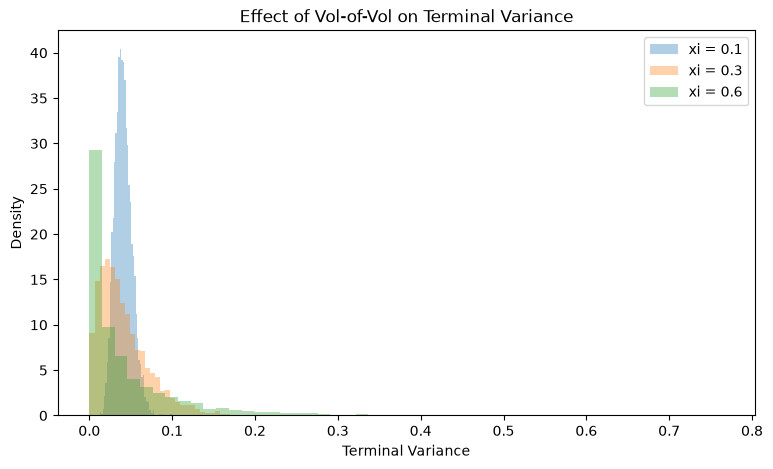

In [12]:
plt.figure(
    figsize=(9, 5),
)

for xi_value in xi_values:

    (
        _,
        _,
        variance_xi,
    ) = simulate_heston_paths(
        S0=S0,
        v0=v0,
        T=T,
        r=r,
        kappa=kappa,
        theta=theta,
        xi=xi_value,
        rho=rho,
        n_paths=5_000,
        n_steps=n_steps,
        seed=123,
    )

    plt.hist(
        variance_xi[:, -1],
        bins=50,
        density=True,
        alpha=0.35,
        label=f"xi = {xi_value}",
    )

plt.xlabel("Terminal Variance")
plt.ylabel("Density")
plt.title(
    "Effect of Vol-of-Vol on Terminal Variance"
)

plt.legend()

plt.savefig(
    figure_dir / "heston_xi_effect.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 6. Correlation and the Leverage Effect

The Heston model allows stock-return shocks and variance shocks to be correlated:

$$
dW_t^S dW_t^v
=
\rho\,dt.
$$

For equity markets, $\rho$ is often considered negative.

A negative value means that negative stock shocks tend to coincide with positive variance shocks.

This mechanism is commonly associated with the leverage effect:

$$
S_t \downarrow
\quad\Rightarrow\quad
v_t \uparrow.
$$

Negative correlation can therefore introduce asymmetry into the return distribution and contributes to downward implied-volatility skew.

In [13]:
rho_values = [
    0.0,
    -0.4,
    -0.7,
]

rho_results = []

return_samples = {}

for rho_value in rho_values:

    (
        _,
        stock_rho,
        variance_rho,
    ) = simulate_heston_paths(
        S0=S0,
        v0=theta,
        T=1.0,
        r=r,
        kappa=kappa,
        theta=theta,
        xi=0.40,
        rho=rho_value,
        n_paths=20_000,
        n_steps=252,
        seed=321,
    )

    log_returns = np.log(
        stock_rho[:, -1] / S0
    )

    return_samples[
        rho_value
    ] = log_returns

    rho_results.append({
        "rho": rho_value,
        "Mean Log Return": np.mean(
            log_returns
        ),
        "Std Log Return": np.std(
            log_returns,
            ddof=1,
        ),
        "Skewness": skew(
            log_returns
        ),
        "Excess Kurtosis": kurtosis(
            log_returns,
            fisher=True,
        ),
    })

rho_results_df = pd.DataFrame(
    rho_results
)

rho_results_df

,rho,Mean Log Return,Std Log Return,Skewness,Excess Kurtosis
0,0.0,0.010552,0.203099,-0.154381,1.169555
1,-0.4,0.010291,0.207972,-0.804466,1.961869
2,-0.7,0.010012,0.211374,-1.269221,3.026844


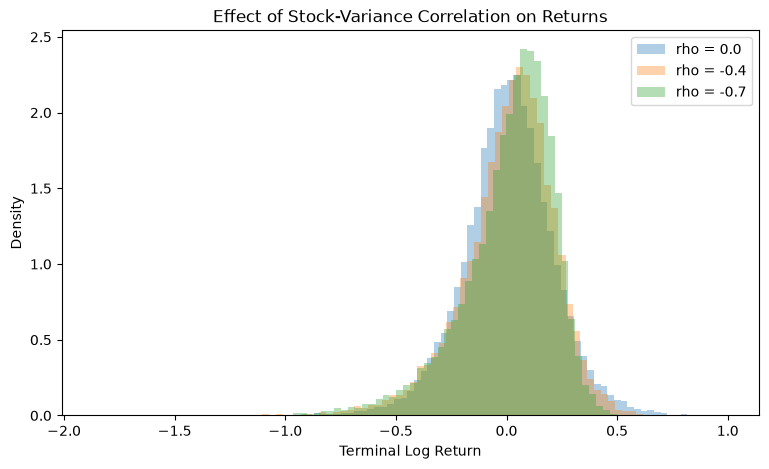

In [14]:
plt.figure(
    figsize=(9, 5),
)

for rho_value in rho_values:

    plt.hist(
        return_samples[
            rho_value
        ],
        bins=80,
        density=True,
        alpha=0.35,
        label=f"rho = {rho_value}",
    )

plt.xlabel("Terminal Log Return")
plt.ylabel("Density")

plt.title(
    "Effect of Stock-Variance Correlation on Returns"
)

plt.legend()

plt.savefig(
    figure_dir / "heston_rho_effect.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 7. Heston versus Constant-Volatility GBM

Under Black-Scholes, terminal log returns are normally distributed because volatility is constant.

Heston introduces random variance and correlated stock-variance shocks.

This allows the return distribution to deviate from the Gaussian benchmark.

The comparison below evaluates whether stochastic volatility generates asymmetry and heavier tails relative to constant-volatility GBM.

In [15]:
comparison_paths = 50_000
comparison_T = 1.0

gbm_sigma = np.sqrt(theta)

gbm_terminal_prices = (
    simulate_terminal_prices(
        S0=S0,
        T=comparison_T,
        r=r,
        sigma=gbm_sigma,
        n_paths=comparison_paths,
        seed=500,
    )
)

gbm_log_returns = np.log(
    gbm_terminal_prices / S0
)

(
    _,
    heston_stock_comparison,
    _,
) = simulate_heston_paths(
    S0=S0,
    v0=theta,
    T=comparison_T,
    r=r,
    kappa=kappa,
    theta=theta,
    xi=0.40,
    rho=-0.70,
    n_paths=comparison_paths,
    n_steps=252,
    seed=500,
)

heston_log_returns = np.log(
    heston_stock_comparison[:, -1]
    / S0
)

In [16]:
distribution_results = pd.DataFrame({
    "Model": [
        "GBM",
        "Heston",
    ],

    "Mean": [
        np.mean(
            gbm_log_returns
        ),
        np.mean(
            heston_log_returns
        ),
    ],

    "Std": [
        np.std(
            gbm_log_returns,
            ddof=1,
        ),
        np.std(
            heston_log_returns,
            ddof=1,
        ),
    ],

    "Skewness": [
        skew(
            gbm_log_returns
        ),
        skew(
            heston_log_returns
        ),
    ],

    "Excess Kurtosis": [
        kurtosis(
            gbm_log_returns,
            fisher=True,
        ),
        kurtosis(
            heston_log_returns,
            fisher=True,
        ),
    ],
})

distribution_results

,Model,Mean,Std,Skewness,Excess Kurtosis
0,GBM,0.008942,0.199506,0.001419,-0.034721
1,Heston,0.010678,0.209619,-1.261820,2.968009


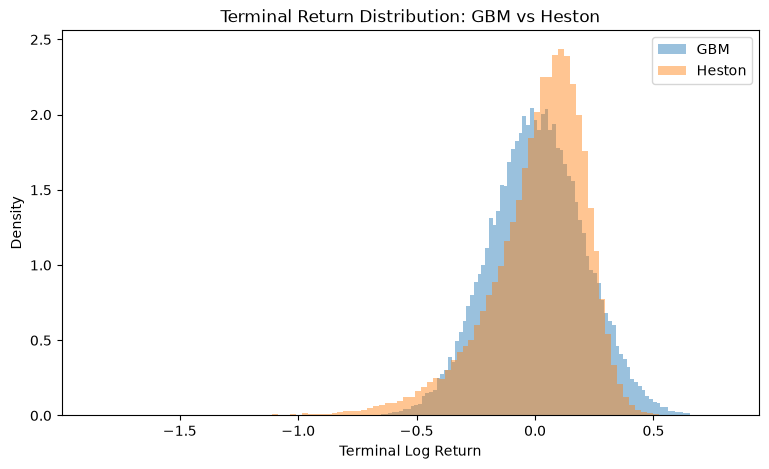

In [17]:
plt.figure(
    figsize=(9, 5),
)

plt.hist(
    gbm_log_returns,
    bins=100,
    density=True,
    alpha=0.45,
    label="GBM",
)

plt.hist(
    heston_log_returns,
    bins=100,
    density=True,
    alpha=0.45,
    label="Heston",
)

plt.xlabel("Terminal Log Return")
plt.ylabel("Density")

plt.title(
    "Terminal Return Distribution: GBM vs Heston"
)

plt.legend()

plt.savefig(
    figure_dir / "heston_vs_gbm_returns.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 8. Interpretation

The experiments provide several numerical insights into the Heston model.

First, the simulated average variance closely follows the analytical expectation

$$
\mathbb E[v_t]
=
\theta
+
(v_0-\theta)e^{-\kappa t},
$$

providing a direct validation of the variance simulation.

Second, the parameter $\kappa$ controls the speed of mean reversion. Larger values cause expected variance to return more rapidly toward the long-run level $\theta$.

Third, increasing $\xi$ increases dispersion in the variance process. This confirms the interpretation of $\xi$ as the volatility of variance.

Fourth, negative stock-variance correlation introduces asymmetry into the return distribution. 
Under the parameter configurations examined here, increasingly
negative values of $\rho$ produce progressively stronger negative
return skewness and higher excess kurtosis.

The GBM benchmark produces almost zero skewness and excess kurtosis,
consistent with the Gaussian log-return structure implied by constant
volatility.

In contrast, the Heston simulation produces substantial negative
skewness and positive excess kurtosis. Under the parameters considered
here, stochastic variance and negative stock-variance correlation
therefore generate distributional features that are absent from the
constant-volatility GBM benchmark.

These mechanisms provide an economic and statistical explanation for why the Heston model can potentially reproduce volatility skews that are absent from the constant-volatility Black-Scholes framework.

## 9. Numerical and Model Limitations

The simulations in this notebook use a positivity-truncated Euler approximation for the variance process.

An important numerical observation is that the minimum simulated
variance can equal zero even when the theoretical Feller condition is
satisfied.

This does not contradict the continuous-time Heston model. Instead,
it results from the discrete Euler approximation: a numerical step may
produce a negative variance value, which is subsequently truncated to
zero by the simulation scheme.

This illustrates the distinction between theoretical model properties
and numerical discretization effects.

This scheme is simple and transparent, but it introduces discretization error and is not the only possible numerical method for simulating Heston dynamics.

More advanced schemes, such as full-truncation Euler or exact / quasi-exact CIR simulation methods, may improve numerical behavior.

In addition, demonstrating realistic variance and return dynamics does not by itself prove that the Heston model provides superior option prices.

That question requires a separate pricing implementation and calibration exercise.

The next stage therefore moves from Heston dynamics to Heston option pricing.

## Conclusion

This experiment implemented and validated stochastic stock-price and variance dynamics under the Heston model.

The variance simulation was benchmarked against the analytical expectation of the CIR variance process, and the simulated average variance closely followed the theoretical mean-reversion path.

Parameter experiments confirmed the economic interpretation of the main Heston parameters:

- $\kappa$ determines the speed of variance mean reversion;
- $\theta$ determines the long-run variance level;
- $\xi$ controls the variability of variance;
- $\rho$ controls the dependence between return and variance shocks.

Negative stock-variance correlation generated asymmetric return distributions, while stochastic variance produced distributional behavior that differed materially from constant-volatility GBM.

These results explain why stochastic-volatility models are capable of generating richer market dynamics than Black-Scholes.

However, dynamic realism alone is not sufficient. The next research question is whether the Heston model can price options accurately and ultimately reduce the model error observed across an implied-volatility surface.

This motivates the next stage: Heston option pricing and numerical validation.